기술적 EDA

In [2]:
# PostgreSQL에서 clean_orders 데이터 불러오기
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
import urllib.parse

load_dotenv('.env')  # .env 파일 읽기

# DB연결정보
user = "postgres"
password = urllib.parse.quote_plus(os.getenv('DB_PW'))
host = "127.0.0.1"
port = '5432'
database = 'ecommerce'

# 엔진 생성
engine = create_engine(f'postgresql://{user}:{password}@{host}:{port}/{database}')

# 데이터 불러오기
data = pd.read_sql("select * from clean_orders", engine)

In [3]:
# 데이터프레임 크기 확인
data.shape

(171, 6)

In [4]:
# 컬럼별 자료형
data.info()

# item_total, cod에서 결측치 존재

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_no      171 non-null    object        
 1   buyer         171 non-null    object        
 2   order_date    171 non-null    datetime64[ns]
 3   item_total    153 non-null    float64       
 4   order_status  171 non-null    object        
 5   cod           147 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 8.1+ KB


In [5]:
# 결측치 체크 => item_total / cod에 결측치 존재
data.isnull().sum()

# item_total 결측치 비율 확인
order_completed = data[data['order_status']=='Delivered to buyer']
item_total_null = order_completed['item_total'].isnull().sum()
item_total_null_ratio = (item_total_null/len(order_completed['item_total'])) * 100
print(item_total_null_ratio)

4.375


order_status가 Delivered to buyer인 것 기준으로 item_total 결측치 약 4프로 => 제거해도 무방하다고 판단하여 제거함

In [6]:
df = order_completed.dropna(subset=['item_total'])

In [7]:
# 숫자형 컬럼 체크
df.describe()

,order_date,item_total
count,153,153.000000
mean,2021-11-05 15:22:03.921568768,582.856209
min,2021-06-13 19:08:00,175.000000
25%,2021-09-20 18:41:00,399.000000
50%,2021-11-13 19:37:00,449.000000
75%,2021-12-15 11:11:00,549.000000
max,2022-02-25 20:44:00,3897.000000
std,NaN,488.100122


In [8]:
# 중복 확인
# 주문번호 기준
print(df['order_no'].duplicated().sum())

# 고객이름 + 주문날짜 기준
print(df.duplicated(subset=['buyer','order_date']).sum())


0
0


In [9]:
# 날짜 범위 확인
# 시작/끝 날짜 확인
print(df['order_date'].max())
print(df['order_date'].min())

# 연-월 단위로 확인
df['year_month'] = df['order_date'].dt.to_period('M')
print(df['year_month'].unique())

2022-02-25 20:44:00
2021-06-13 19:08:00
<PeriodArray>
['2021-07', '2021-10', '2021-11', '2021-09', '2021-06', '2021-08', '2022-02',
 '2022-01', '2021-12']
Length: 9, dtype: period[M]


C:\Users\82104\AppData\Local\Temp\ipykernel_408\1715375098.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year_month'] = df['order_date'].dt.to_period('M')


비즈니스 탐색 EDA

가설 1. 매출은 소수 고객에게 집중되어 있을 것

가설 2. 연말 소비 증가로 월 평균 대비 매출이 높을 것

가설 3. 재구매 고객은 전체 매출에서 높은 비중을 차지할 것

In [10]:
import matplotlib.pyplot as plt
import numpy as np

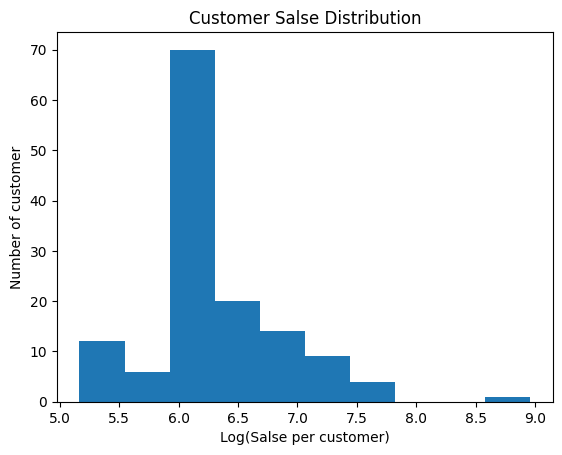

상위 10% 고객 배출 비중 계산 : 29.06691187189522


In [11]:
# 가설 1에 대한 비즈니스 탐색 EDA 진행 
customer_sales = df.groupby('buyer')['item_total'].sum()
reset_index_customer_sales = customer_sales.reset_index()

# 고객별 매출 분포 그래프
plt.figure()
plt.hist(np.log(reset_index_customer_sales['item_total']))
plt.xlabel('Log(Salse per customer)')
plt.ylabel('Number of customer')
plt.title('Customer Salse Distribution')

plt.show()

# 상위 10% 고객 매출 비중 계산
sort_customer_sales = customer_sales.sort_values(ascending=False)

top_ten = int(len(sort_customer_sales)*0.1)

top_customer = sort_customer_sales.iloc[:top_ten].sum()

top_ten_ratio = (top_customer / (customer_sales.sum())) * 100

print('상위 10% 고객 배출 비중 계산 :',top_ten_ratio)



월별 매출 추이 : year_month
2021-06     1698.0
2021-07     2395.0
2021-08     7640.0
2021-09     9084.0
2021-10    10979.0
2021-11    13672.0
2021-12    28983.0
2022-01     7013.0
2022-02     7713.0
Freq: M, Name: item_total, dtype: float64
월별 매출 평균 : year_month
2021-06    242.571429
2021-07    399.166667
2021-08    636.666667
2021-09    534.352941
2021-10    477.347826
2021-11    525.846154
2021-12    852.441176
2022-01    467.533333
2022-02    593.307692
Freq: M, Name: item_total, dtype: float64
연말(11월+12월) 매출 평균이 전체 평균 매출에서의 비중 : 29.14398745749563


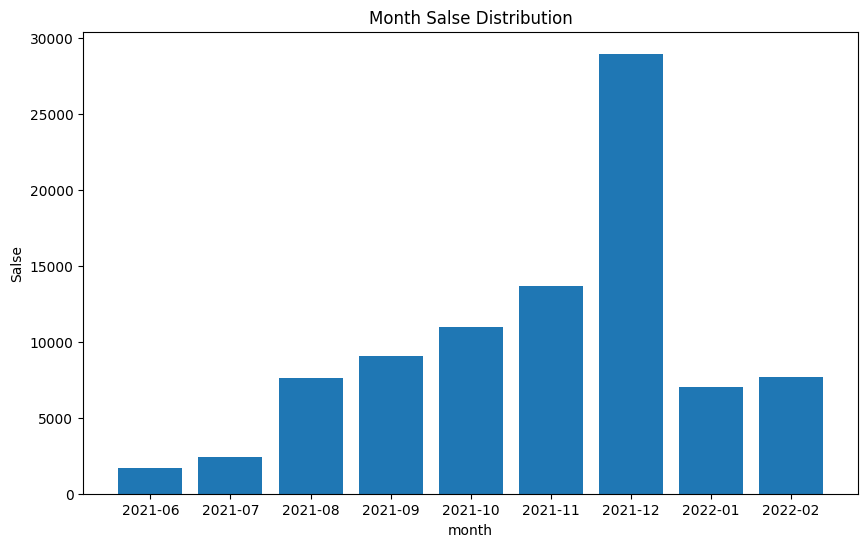

In [12]:
# 가설 2에 대한 비즈니스 탐색 EDA 진행 
# 월별 매출 추이
month_sales = df.groupby('year_month')['item_total'].sum()
print("월별 매출 추이 :",month_sales)

plt.figure(figsize=(10,6))
plt.bar(month_sales.index.astype(str),month_sales.values)
plt.xlabel('month')
plt.ylabel('Salse')
plt.title('Month Salse Distribution')

# 월별 매출 평균
month_sales_mean = df.groupby('year_month')['item_total'].mean()
print("월별 매출 평균 :",month_sales_mean)

# 연말(11월+12월) 매출 평균이 전체 평균 매출에서 몇퍼센트를 차지하는지 계산
nov_sales_mean = month_sales_mean['2021-11']
dec_sales_mean = month_sales_mean['2021-12']
month_sales_mean_sum = month_sales_mean.sum()
dec_ratio = ((nov_sales_mean + dec_sales_mean) / month_sales_mean_sum) * 100
print("연말(11월+12월) 매출 평균이 전체 평균 매출에서의 비중 :",dec_ratio)


In [15]:
# 가설 3에 대한 비즈니스 탐색 EDA 진행 
# 2회 이상 구매한 고객의 비율
repeat_customer = df.groupby('buyer').size().reset_index(name='purchase_count')
repeat_customers = repeat_customer[repeat_customer['purchase_count'] >= 2]
repeat_customer_ratio = (repeat_customers['buyer'].count() / repeat_customer['buyer'].count()) * 100
print("2회 이상 구매한 고객의 비율 :",repeat_customer_ratio)

# 재구매 고객 매출 비중
customer_sales = df.groupby('buyer')['item_total'].sum()
print(customer_sales.sum())
repeat_customer_salse = customer_sales[repeat_customers['buyer']].sum()
print(repeat_customer_salse)
repeat_ratio = (repeat_customer_salse.sum()/customer_sales.sum()) * 100
print("재구매 고객 매출 비중 :",repeat_ratio.sum())

2회 이상 구매한 고객의 비율 : 12.5
89177.0
25110.0
재구매 고객 매출 비중 : 28.15748455319197


In [14]:
# 추가 비즈니스 탐색 EDA
# 결제수단별 매출 비중
# Credit Card는 인터넷 결제를 의미하고 Cash On Delivery는 물품 수령 후 결제를 의미한다.
cod_sales = df.groupby('cod')['item_total'].sum()
print(cod_sales)

sales = df['item_total'].sum()
#print(sales)

cod_ratio = ((cod_sales['Cash On Delivery']) / sales) * 100
credit_card_ratio = ((cod_sales['Credit Card']) / sales) * 100

print("인터넷 결제 비율: ",credit_card_ratio)
print("물품 수령 후 결제 비율: ",cod_ratio)

# 결제수단별 평균 주문 금액 비교
cod_sales_mean = df.groupby('cod')['item_total'].mean()
print(cod_sales_mean)

cod
Cash On Delivery    22914.0
Credit Card         55905.0
Name: item_total, dtype: float64
인터넷 결제 비율:  62.689931260302544
물품 수령 후 결제 비율:  25.694966190833963
cod
Cash On Delivery    572.850000
Credit Card         607.663043
Name: item_total, dtype: float64
